# Timing Benchmark: Model Inference vs. Geodesic Interpolation

This notebook compares the computational cost of:
1. **Model inference**: one forward pass of the trained PINN.
2. **Geodesic interpolation**: one call to `fractional_matrix_power` (the method from Schilling et al.).

Both are evaluated for systems of 2 to 6 qubits.
Results are averaged over multiple repetitions to obtain stable estimates.

In [1]:
import numpy as np
import torch
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from scipy.linalg import fractional_matrix_power
from req_prog.architectures import UnitaryModel
from req_prog.useful_functions import closest_unitary
from req_prog.h_magnus import fid_pros

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
N_QUBITS_LIST = [2, 3, 4, 5, 6]
DELTA_T_BENCHMARK = 0.1   # model trained with this Δt (any works; we just need a loaded model)
N_REPS = 500               # repetitions per method per system size
SEED = 42
rng = np.random.default_rng(SEED)

In [3]:
def load_model(n_qubits: int, delta_t: float, device: str = "cpu") -> torch.nn.Module:
    """Load a trained UnitaryModel from disk and set it to eval mode."""
    model = UnitaryModel(n_qubits=n_qubits)
    path = f"models/models-full-loss/model{n_qubits}_deltat-{delta_t}.pth"
    model.load_state_dict(torch.load(path, map_location=device))
    model = model.to(device=device)
    model.eval()
    return model


def warmup_model(model: torch.nn.Module, n_reps: int = 3) -> None:
    """Warm up the GPU by running a few dummy inferences."""
    device = next(model.parameters()).device
    with torch.no_grad():
        for _ in range(n_reps):
            t_query = torch.tensor(
                [rng.uniform(0.0, 1.0)], dtype=torch.float32, device=device
            )
            _ = model(t_query)
    if device.type == "cuda":
        torch.cuda.synchronize(device)


def time_model_inference(model: torch.nn.Module, n_reps: int) -> np.ndarray:
    """
    Measure the wall-clock time of a single forward pass.

    A random time in [0, 1] is drawn for each repetition so that
    the benchmark is representative of arbitrary query times.
    """
    device = next(model.parameters()).device
    times = []
    with torch.no_grad():
        for _ in range(n_reps):
            t_query = torch.tensor(
                [rng.uniform(0.0, 1.0)], dtype=torch.float32, device=device
            )
            if device.type == "cuda":
                torch.cuda.synchronize(device)
            t0 = time.perf_counter()
            _ = model(t_query)
            if device.type == "cuda":
                torch.cuda.synchronize(device)
            t1 = time.perf_counter()
            times.append(t1 - t0)
    return np.array(times)


def time_geodesic_interpolation(
    U_known: np.ndarray, n_reps: int
) -> np.ndarray:
    """
    Measure the wall-clock time of one geodesic interpolation step.

    For each repetition:
      - A random query time t ∈ [0, 1] is drawn.
      - The two bracketing known unitaries are located.
      - The interpolated unitary is computed as (U1 @ U0†)^alpha @ U0
        using fractional_matrix_power.

    Parameters
    ----------
    U_known : np.ndarray
        Array of shape (K, d, d) with K unitaries on a uniform time grid
        covering [0, 1].
    """
    K = U_known.shape[0]
    time_grid = np.linspace(0.0, 1.0, K)
    delta_t = time_grid[1] - time_grid[0]

    times = []
    for _ in range(n_reps):
        t_query = rng.uniform(0.0, 1.0)

        # Locate left bracket (same logic as left_interval_value)
        if t_query >= time_grid[-1]:
            idx = K - 2
        else:
            idx = int(np.searchsorted(time_grid, t_query, side="right") - 1)
            idx = max(idx, 0)

        alpha = (t_query - time_grid[idx]) / delta_t
        U0 = U_known[idx]
        U1 = U_known[idx + 1]

        t0 = time.perf_counter()
        W = U1 @ np.conj(U0).T
        _ = fractional_matrix_power(W, alpha) @ U0
        t1 = time.perf_counter()
        times.append(t1 - t0)

    return np.array(times)

In [4]:
# ── Run benchmark ─────────────────────────────────────────────────────────────
results = {}   # {n_qubits: {"model": arr, "interp": arr}}
previous_device = None

for n in N_QUBITS_LIST:
    device = "cpu" if n >= 6 else "cpu"
    
    # Warm-up cuando cambiamos a GPU
    if device == "cuda:0" and previous_device != "cuda:0":
        print(f"GPU warm-up with N={n} ...", end=" ", flush=True)
        model = load_model(n, DELTA_T_BENCHMARK, device=device)
        warmup_model(model)
        print("done")
    
    print(f"Benchmarking N={n} qubits ...", end=" ", flush=True)

    # Load model and known unitaries (Δt=0.1 grid → 13 time points)
    model = load_model(n, DELTA_T_BENCHMARK, device=device)
    U_known = np.load(f"dataframe/unitary_N{n}.npy")   # shape (K, d, d)

    t_model  = time_model_inference(model, N_REPS)
    t_interp = time_geodesic_interpolation(U_known, N_REPS)

    results[n] = {"model": t_model, "interp": t_interp}
    print(
        f"model {t_model.mean()*1e3:.3f} ± {t_model.std()*1e3:.3f} ms  |  "
        f"interp {t_interp.mean()*1e3:.3f} ± {t_interp.std()*1e3:.3f} ms"
    )
    
    previous_device = device

print("Done.")

Benchmarking N=2 qubits ... model 0.027 ± 0.015 ms  |  interp 0.463 ± 2.238 ms
Benchmarking N=3 qubits ... model 0.027 ± 0.011 ms  |  interp 0.423 ± 0.044 ms
Benchmarking N=4 qubits ... model 0.036 ± 0.011 ms  |  interp 0.576 ± 0.053 ms
Benchmarking N=5 qubits ... model 0.061 ± 0.014 ms  |  interp 1.074 ± 0.042 ms
Benchmarking N=6 qubits ... model 0.709 ± 0.087 ms  |  interp 3.893 ± 0.353 ms
Done.


In [5]:
# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'N':>4}  {'Model mean (ms)':>16}  {'Model std (ms)':>14}  "
      f"{'Interp mean (ms)':>17}  {'Interp std (ms)':>15}  {'Speedup':>8}")
print("-" * 82)

for n in N_QUBITS_LIST:
    m  = results[n]["model"].mean()  * 1e3
    ms = results[n]["model"].std()   * 1e3
    p  = results[n]["interp"].mean() * 1e3
    ps = results[n]["interp"].std()  * 1e3
    speedup = p / m
    print(f"{n:>4}  {m:>16.4f}  {ms:>14.4f}  {p:>17.4f}  {ps:>15.4f}  {speedup:>8.2f}x")

   N   Model mean (ms)  Model std (ms)   Interp mean (ms)  Interp std (ms)   Speedup
----------------------------------------------------------------------------------
   2            0.0274          0.0151             0.4627           2.2383     16.88x
   3            0.0271          0.0112             0.4233           0.0435     15.63x
   4            0.0359          0.0107             0.5757           0.0526     16.02x
   5            0.0610          0.0145             1.0743           0.0423     17.62x
   6            0.7085          0.0865             3.8928           0.3534      5.49x


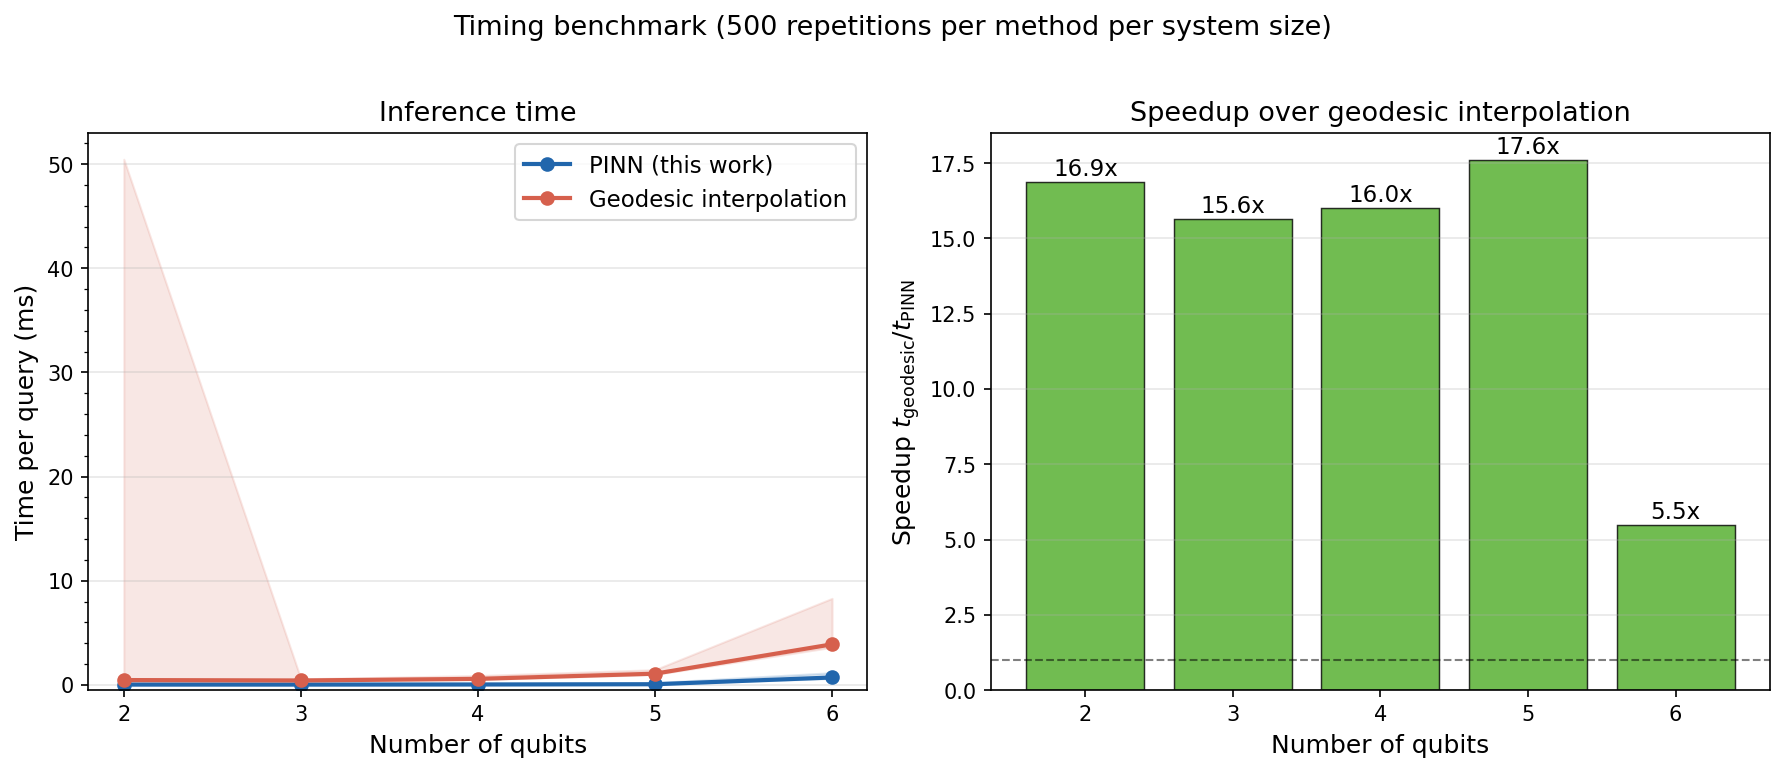

Figure saved to figures/timing_benchmark.pdf


In [6]:
# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

x      = np.array(N_QUBITS_LIST)
colors = {"model": "#2166ac", "interp": "#d6604d"}
labels = {"model": "PINN (this work)", "interp": "Geodesic interpolation"}

# ── Left panel: absolute times ────────────────────────────────────────────────
ax = axes[0]

# PINN con min/max
means_model = np.array([results[n]["model"].mean() * 1e3 for n in N_QUBITS_LIST])
mins_model  = np.array([results[n]["model"].min()  * 1e3 for n in N_QUBITS_LIST])
maxs_model  = np.array([results[n]["model"].max()  * 1e3 for n in N_QUBITS_LIST])
ax.plot(x, means_model, "o-", color=colors["model"], label=labels["model"], lw=2)
ax.fill_between(
    x,
    mins_model,
    maxs_model,
    alpha=0.15, color=colors["model"]
)

# Geodésico con min/max
means_interp = np.array([results[n]["interp"].mean() * 1e3 for n in N_QUBITS_LIST])
mins_interp  = np.array([results[n]["interp"].min()  * 1e3 for n in N_QUBITS_LIST])
maxs_interp  = np.array([results[n]["interp"].max()  * 1e3 for n in N_QUBITS_LIST])
ax.plot(x, means_interp, "o-", color=colors["interp"], label=labels["interp"], lw=2)
ax.fill_between(
    x,
    mins_interp,
    maxs_interp,
    alpha=0.15, color=colors["interp"]
)

ax.set_xlabel("Number of qubits", fontsize=12)
ax.set_ylabel("Time per query (ms)", fontsize=12)
ax.set_title("Inference time", fontsize=13)
ax.set_xticks(x)
ax.set_ylim(bottom=-0.5)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# ── Right panel: speedup ratio (geodesic / PINN) ──────────────────────────────
ax2 = axes[1]
speedup = np.array(
    [results[n]["interp"].mean() / results[n]["model"].mean()
     for n in N_QUBITS_LIST]
)
ax2.bar(x, speedup, color="#4dac26", alpha=0.8, edgecolor="k", linewidth=0.7)
ax2.axhline(1, color="k", lw=1, ls="--", alpha=0.5)
ax2.set_xlabel("Number of qubits", fontsize=12)
ax2.set_ylabel(r"Speedup $t_\mathrm{geodesic} / t_\mathrm{PINN}$", fontsize=12)
ax2.set_title("Speedup over geodesic interpolation", fontsize=13)
ax2.set_xticks(x)
ax2.set_ylim([0, None])
ax2.grid(axis="y", alpha=0.3)

# Annotate bars
for xi, s in zip(x, speedup):
    ax2.text(xi, s + 0.05, f"{s:.1f}x", ha="center", va="bottom", fontsize=11)

plt.suptitle(
    f"Timing benchmark ({N_REPS} repetitions per method per system size)",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig("figures/timing_benchmark.pdf", bbox_inches="tight")
plt.show()
print("Figure saved to figures/timing_benchmark.pdf")

N=2: PINN = 0.99914 | PINN+SVD = 0.99935 | Geodesic = 0.99980
N=3: PINN = 0.99773 | PINN+SVD = 0.99858 | Geodesic = 0.99951
N=4: PINN = 0.99965 | PINN+SVD = 0.99991 | Geodesic = 0.99889
N=5: PINN = 0.99994 | PINN+SVD = 0.99997 | Geodesic = 0.99971
N=6: PINN = 0.99954 | PINN+SVD = 0.99971 | Geodesic = 0.99949


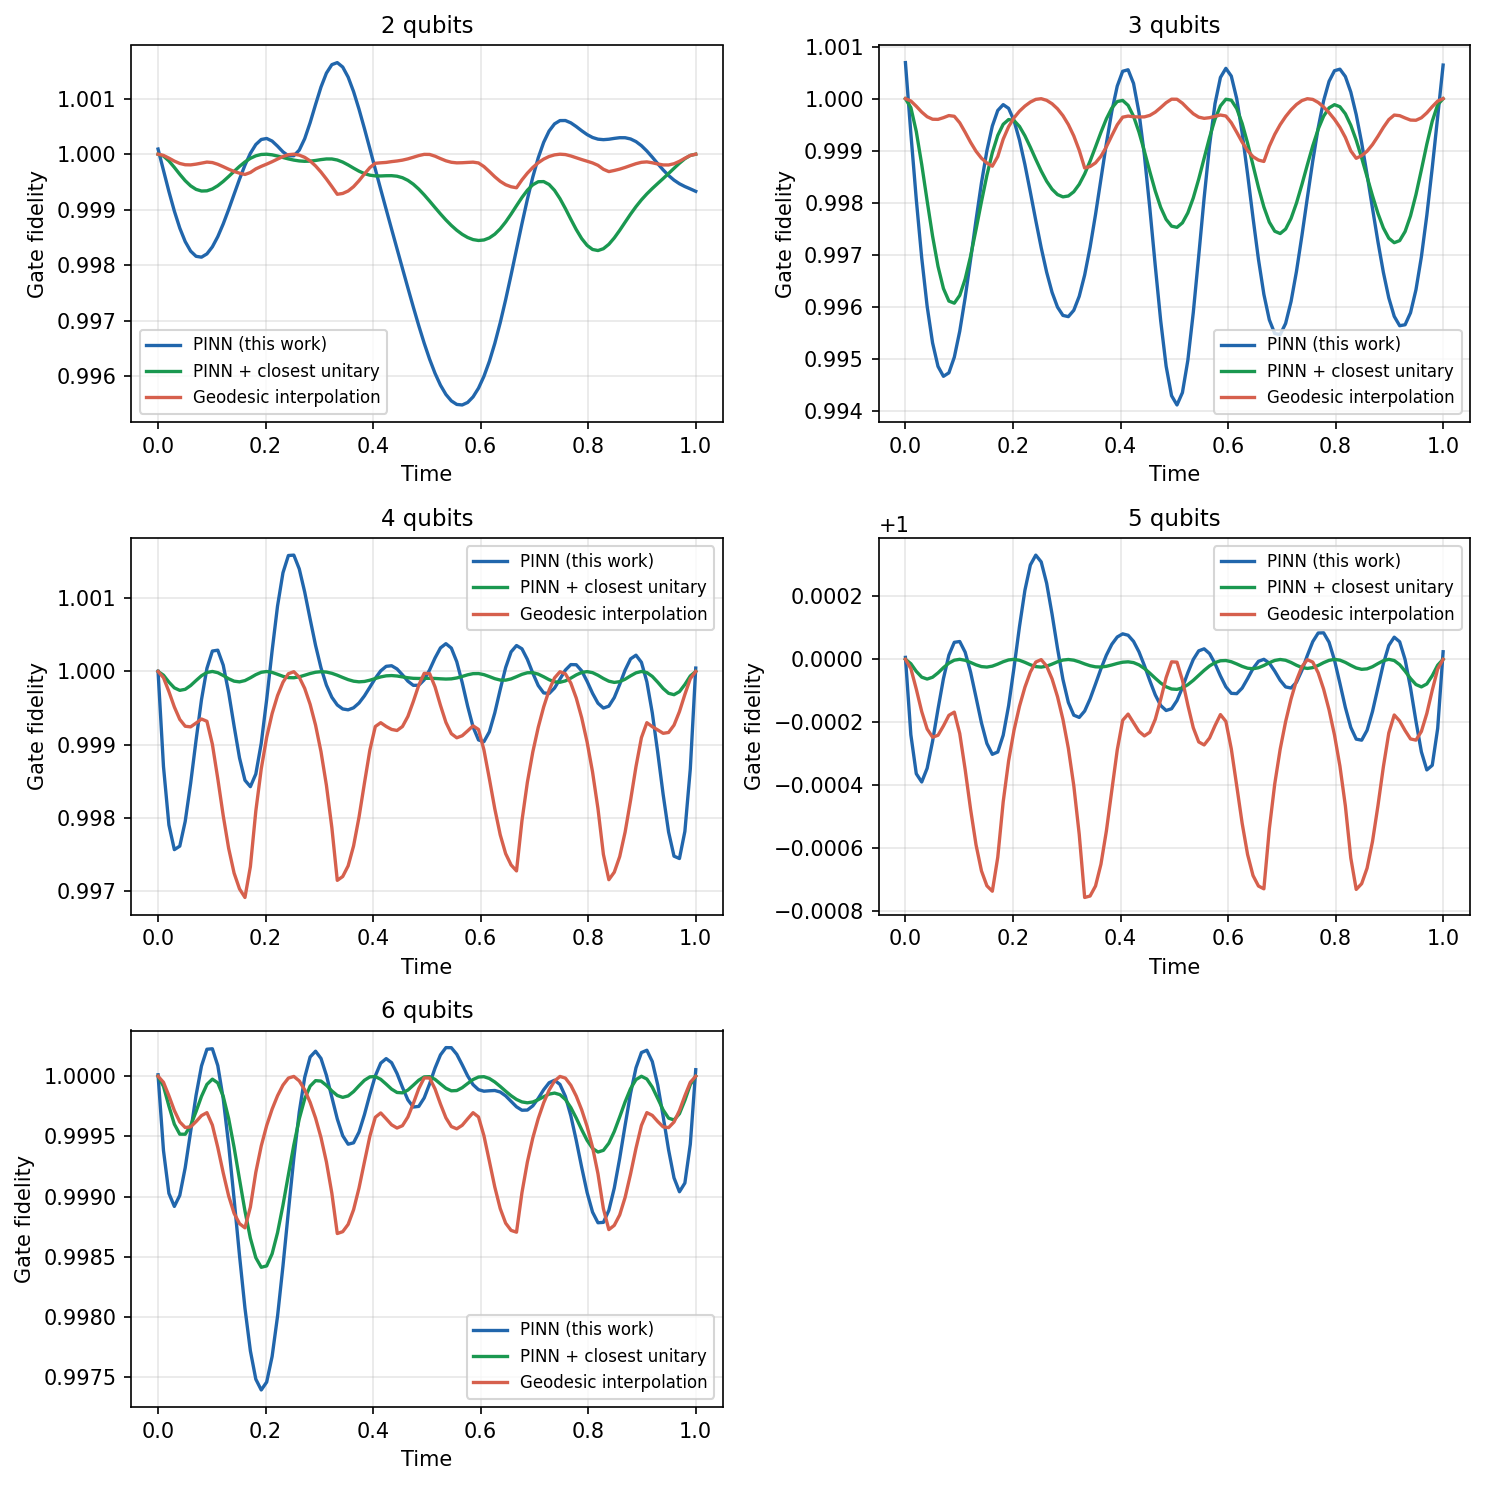

In [9]:
# ── Accuracy comparison: PINN (raw + SVD) vs Geodesic ─────────────────────────
time_grid = np.linspace(0.0, 1.0, 100)
fid_results = {}   # {n: {"model": arr, "model_svd": arr, "interp": arr}}

for n in N_QUBITS_LIST:
    model    = load_model(n, DELTA_T_BENCHMARK)
    U_known  = np.load(f"dataframe/unitary_N{n}.npy")
    U_target = np.load(f"dataframe/unitary_N{n}_test.npy")  # (100, d, d)
    K        = U_known.shape[0]
    t_known  = np.linspace(0.0, 1.0, K)
    delta_t  = t_known[1] - t_known[0]

    fids_model     = []
    fids_model_svd = []
    fids_interp    = []

    with torch.no_grad():
        for idx, t in enumerate(time_grid):
            U_ref = U_target[idx]

            # PINN (raw)
            t_tensor = torch.tensor([t], dtype=torch.float32)
            U_pred   = model(t_tensor)[0].detach().numpy()
            fids_model.append(fid_pros(U_pred, U_ref))

            # PINN (closest unitary via SVD)
            U_pred_svd = closest_unitary(U_pred)
            fids_model_svd.append(fid_pros(U_pred_svd, U_ref))

            # Geodesic
            if t >= t_known[-1]:
                i_left = K - 2
            else:
                i_left = max(int(np.searchsorted(t_known, t, side="right") - 1), 0)
            alpha = (t - t_known[i_left]) / delta_t
            U0    = U_known[i_left]
            U1    = U_known[i_left + 1]
            W     = U1 @ np.conj(U0).T
            U_geo = fractional_matrix_power(W, alpha) @ U0
            fids_interp.append(fid_pros(U_geo, U_ref))

    fid_results[n] = {
        "model"     : np.array(fids_model),
        "model_svd" : np.array(fids_model_svd),
        "interp"    : np.array(fids_interp)
    }
    print(
        f"N={n}: PINN = {np.mean(fids_model):.5f} | "
        f"PINN+SVD = {np.mean(fids_model_svd):.5f} | "
        f"Geodesic = {np.mean(fids_interp):.5f}"
    )

# ── Figure: fidelity comparison (raw + SVD) ───────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(10, 10), dpi=150, sharey=False)
axes = axes.flatten()

for idx, n in enumerate(N_QUBITS_LIST):
    ax = axes[idx]
    for key, color, label in [
        ("model",     "#2166ac", "PINN (this work)"),
        ("model_svd", "#1a9850", "PINN + closest unitary"),
        ("interp",    "#d6604d", "Geodesic interpolation")
    ]:
        fids = fid_results[n][key]
        ax.plot(time_grid, fids, color=color, lw=1.6, label=label)

    ax.set_title(f"{n} qubits", fontsize=11)
    ax.set_xlabel("Time", fontsize=10)
    ax.set_ylabel("Gate fidelity", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Ocultar panel vacío
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig("figures/accuracy_comparison_small.pdf", bbox_inches="tight")
plt.show()